# Benchmark Composition — Category Histograms (4k common subsample)

Question counts over the **original benchmark** only (the `claims` table, one
row per question — no model results). Same 4,000 claim ids used in
[model_evaluation_analysis.ipynb](model_evaluation_analysis.ipynb), built by
`tools/build_subsample_results_db.py` → `results/results_am_subsample.db`.

**Consolidation rules**

| Category | Source field | Rule |
|---|---|---|
| **Answers** | `label_original` (== `metadata.correct_answer_index`) | the correct multiple-choice position, mapped `0→A, 1→B, 2→C, 3→D` |
| **Years of exams** | `claim_date` | parsed numerically to the exam year |

Each claim contributes once (deduplicated from the 112k agent×model result
rows), so the histograms describe the benchmark itself, not any model run.

In [10]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("../results/results_am_subsample.db")

# Original benchmark questions for the SAME 4k common subsample (no results).
claims = pd.read_sql_query(
    "SELECT id, topic, claim_date, label_original FROM claims", conn)

# --- Consolidation rules (see header) -----------------------------------
ANSWER_LABELS = {0: "A (0)", 1: "B (1)", 2: "C (2)", 3: "D (3)"}
claims["answer"]       = pd.to_numeric(claims["label_original"], errors="coerce").astype("Int64")
claims["answer_label"] = claims["answer"].map(ANSWER_LABELS)
claims["year"]         = pd.to_numeric(claims["claim_date"], errors="coerce").astype("Int64")

print(f"{len(claims):,} unique benchmark questions (4k common subsample)")
claims.head(3)

4,000 unique benchmark questions (4k common subsample)


,id,topic,claim_date,label_original,answer,answer_label,year
0,6,Przyroda,2010,3,3,D (3),2010
1,14,Matematyka,2012,0,0,A (0),2012
2,19,Przyroda,2007,1,1,B (1),2007


## Histograms — questions per category

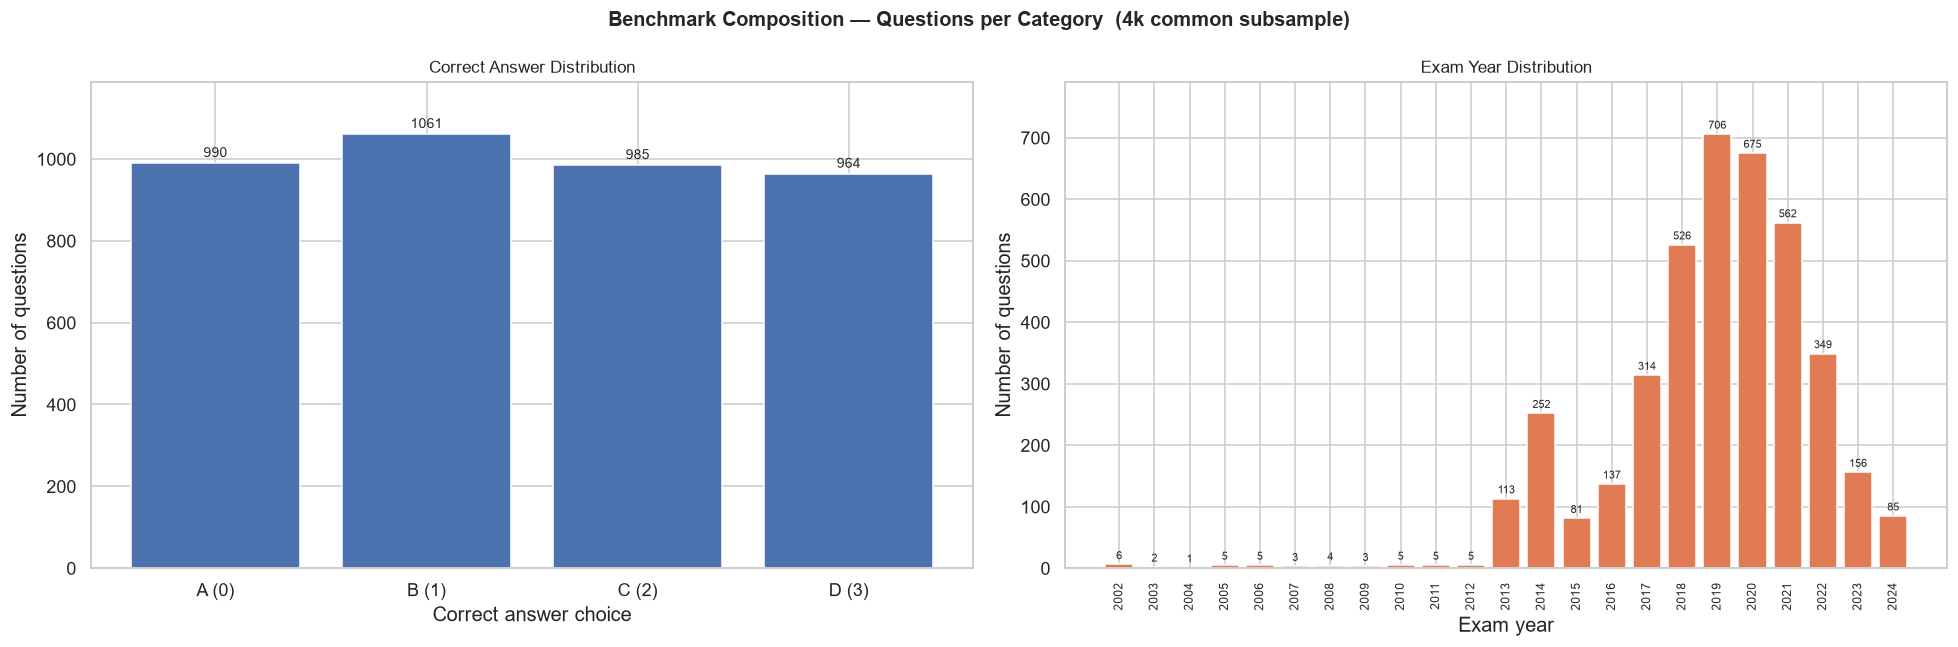

In [11]:
# Two histograms over the original benchmark — questions per category
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Benchmark Composition — Questions per Category  (4k common subsample)",
             fontsize=13, fontweight="bold")

# 1) Correct answer (A-D / 0-3)
ans = claims["answer_label"].value_counts().reindex([ANSWER_LABELS[i] for i in range(4)])
b1 = axes[0].bar(ans.index, ans.values, color="#4C72B0", edgecolor="white")
axes[0].bar_label(b1, fmt="%d", padding=2, fontsize=9)
axes[0].set_title("Correct Answer Distribution", fontsize=11)
axes[0].set_xlabel("Correct answer choice"); axes[0].set_ylabel("Number of questions")
axes[0].margins(y=0.12)

# 2) Exam year
yr = claims["year"].value_counts().sort_index()
b2 = axes[1].bar(yr.index.astype(int).astype(str), yr.values, color="#E07B54", edgecolor="white")
axes[1].bar_label(b2, fmt="%d", padding=2, fontsize=7)
axes[1].set_title("Exam Year Distribution", fontsize=11)
axes[1].set_xlabel("Exam year"); axes[1].set_ylabel("Number of questions")
axes[1].tick_params(axis="x", labelrotation=90, labelsize=8)
axes[1].margins(y=0.12)

plt.tight_layout(); plt.show()

## Subsample vs full benchmark — representativeness

Compare the 4k common subsample against the **full** benchmark
(`data/benchmarks/am_benchmark.db`, 18,820 questions) on **exam year** and
**topic family**. Counts are normalised to **% of questions** so the ~4.7×
size difference doesn't distort the shapes — close bars mean the subsample is
representative.

`topic_family` consolidates the 154 raw topics: exam-code prefixes (`R.13`,
`M.39`, …) collapse to `R (exam code)`, `M (exam code)`, …; named subjects
(Matematyka, Fizyka, …) stay as-is — same rule as model_evaluation_analysis.

In [12]:
import re

# Full (original) benchmark — same columns as the subsample claims table.
full = pd.read_sql_query(
    "SELECT id, topic, claim_date, label_original FROM claims",
    sqlite3.connect("file:../data/benchmarks/am_benchmark.db?mode=ro", uri=True))
full["year"] = pd.to_numeric(full["claim_date"], errors="coerce").astype("Int64")

def topic_family(t):
    t = str(t)
    m = re.match(r"^([A-Za-z]+)\.\d", t)   # exam codes like R.13, M.39
    return (m.group(1).upper() + " (exam code)") if m else t

for d in (claims, full):
    d["topic_family"] = d["topic"].apply(topic_family)

print(f"full benchmark: {len(full):,} questions  |  4k subsample: {len(claims):,}")

full benchmark: 18,820 questions  |  4k subsample: 4,000


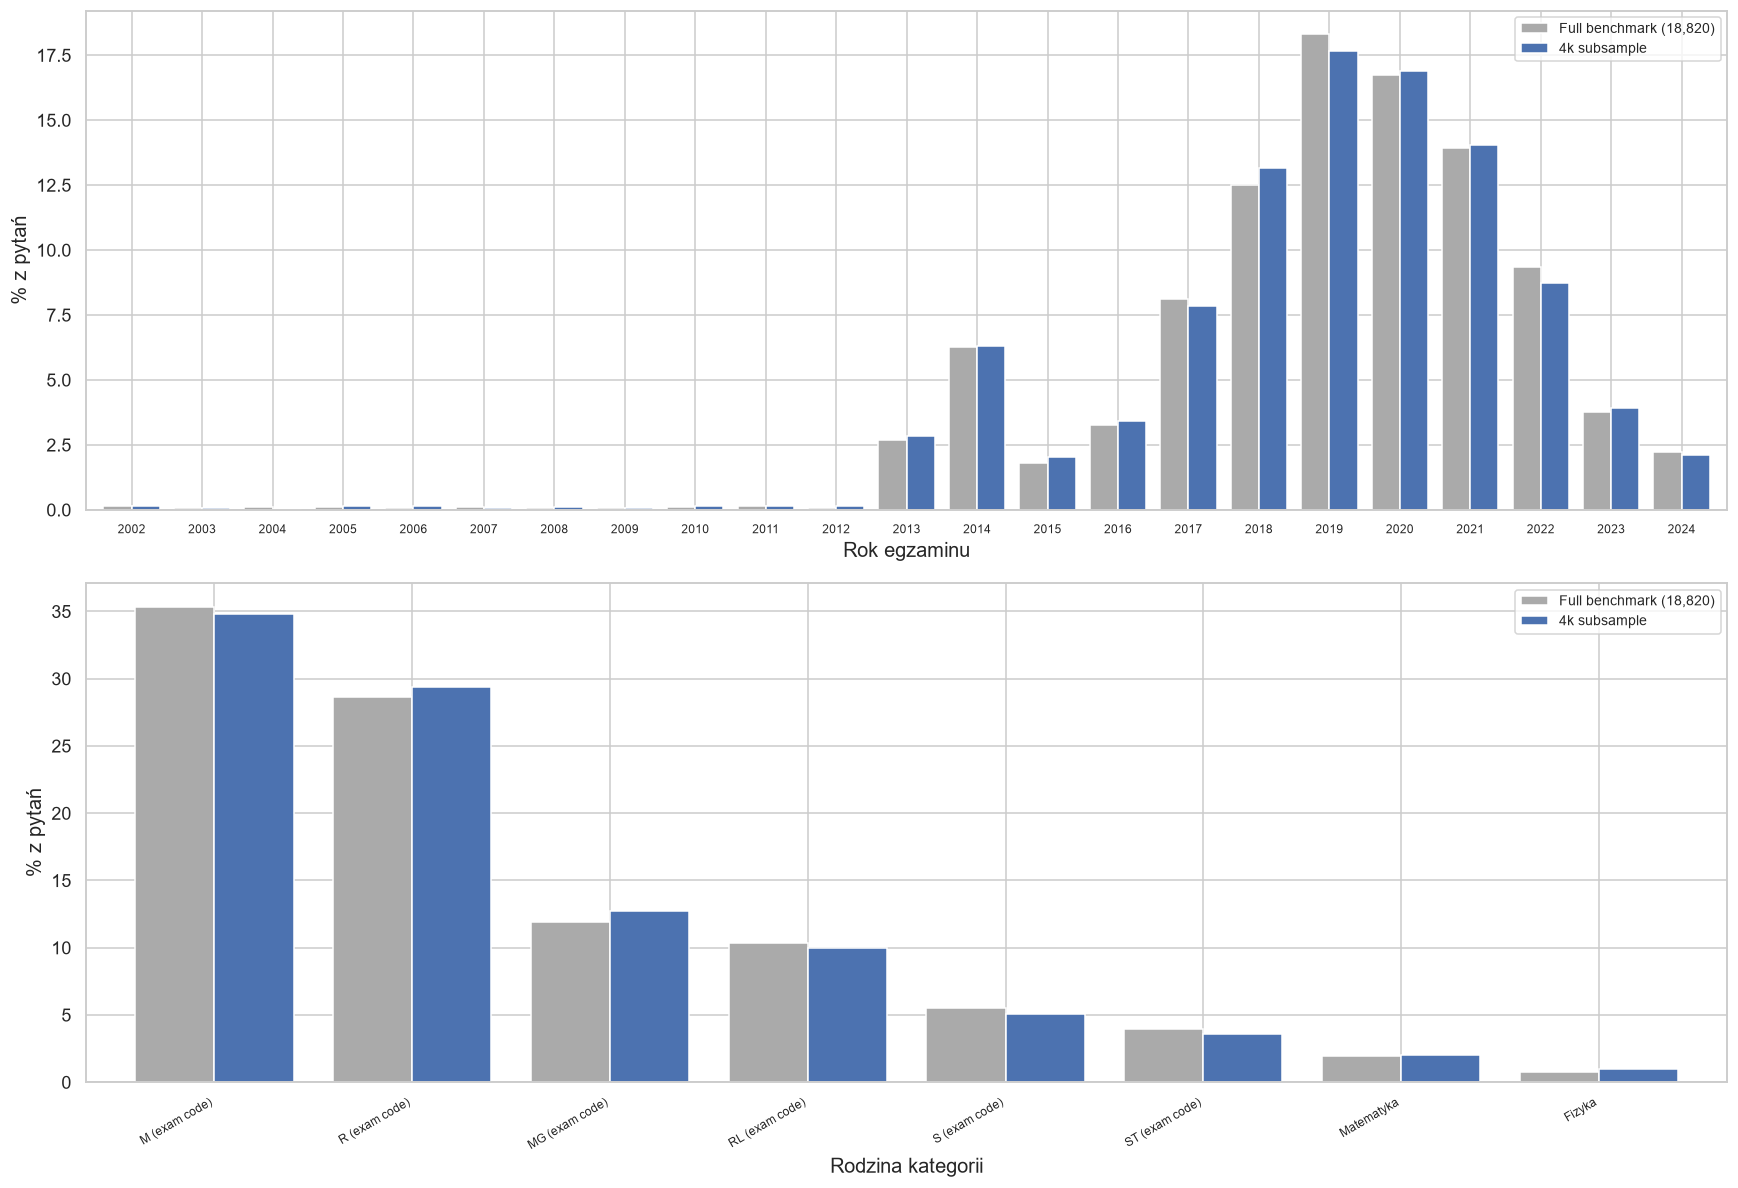

In [29]:
# Two comparisons (% of questions): subsample vs full benchmark
CMP_PALETTE = {"Full benchmark (18,820)": "#aaaaaa", "4k subsample": "#4C72B0"}

def pct_compare(col, order):
    out = pd.DataFrame({
        "Full benchmark (18,820)": full[col].value_counts(normalize=True) * 100,
        "4k subsample":            claims[col].value_counts(normalize=True) * 100,
    })
    return out.reindex(order).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# 1) Exam year
yc = pct_compare("year", sorted(full["year"].dropna().unique()))
yc.index = yc.index.astype(int).astype(str)
yc.plot.bar(ax=axes[0], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[0].set_xlabel("Rok egzaminu"); axes[0].set_ylabel("% z pytań")
axes[0].tick_params(axis="x", labelrotation=0, labelsize=8); axes[0].legend(fontsize=9)

# 2) Topic family (ordered by full-benchmark frequency)
tf_order = full["topic_family"].value_counts().index
tc = pct_compare("topic_family", tf_order)
tc = tc[tc.max(axis=1) >= 1]   # drop families below 1% in BOTH series
tc.plot.bar(ax=axes[1], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[1].set_xlabel("Rodzina kategorii"); axes[1].set_ylabel("% z pytań")
axes[1].tick_params(axis="x", labelrotation=30, labelsize=8); axes[1].legend(fontsize=9)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout(); plt.show()

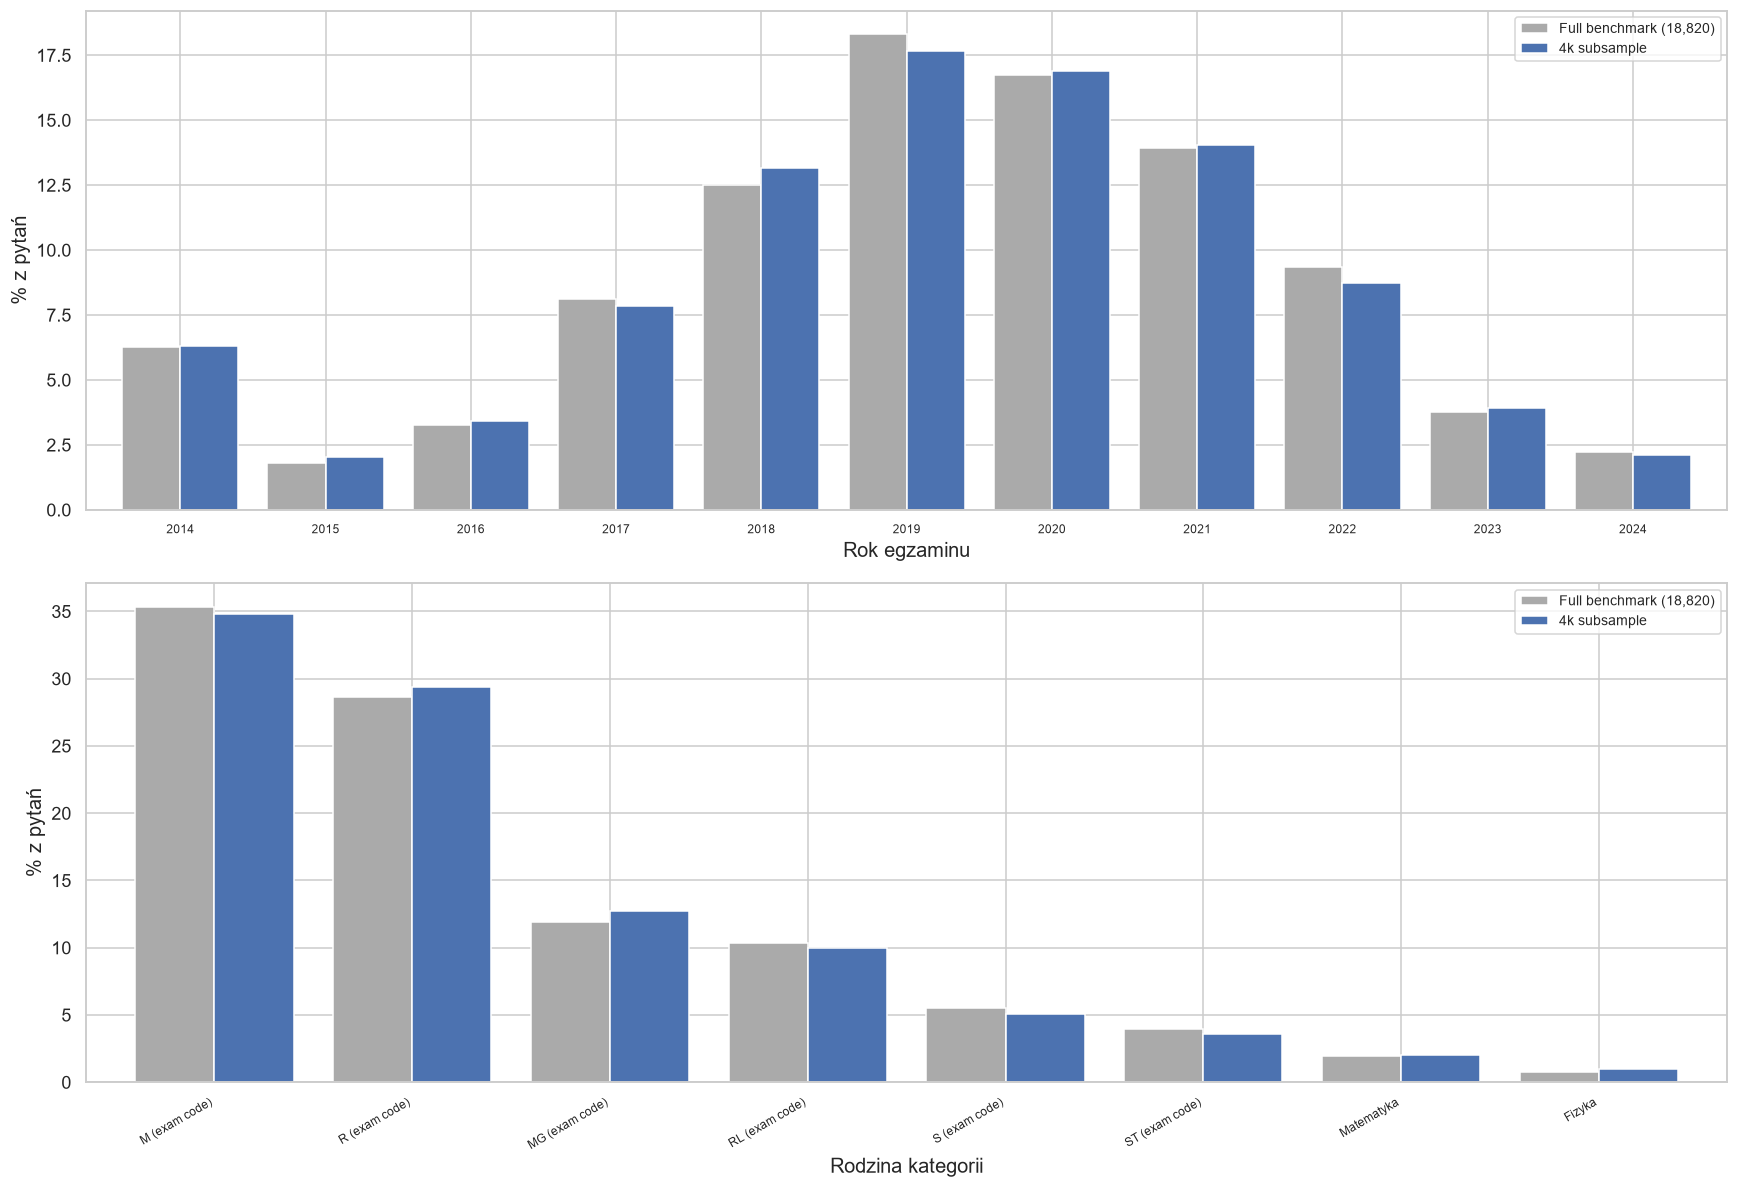

In [31]:
# Two comparisons (% of questions): subsample vs full benchmark
CMP_PALETTE = {"Full benchmark (18,820)": "#aaaaaa", "4k subsample": "#4C72B0"}

def pct_compare(col, order):
    out = pd.DataFrame({
        "Full benchmark (18,820)": full[col].value_counts(normalize=True) * 100,
        "4k subsample":            claims[col].value_counts(normalize=True) * 100,
    })
    return out.reindex(order).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# 1) Exam year
years = [y for y in sorted(full["year"].dropna().unique()) if y > 2013]
yc = pct_compare("year", years)
yc.index = yc.index.astype(int).astype(str)
yc.plot.bar(ax=axes[0], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[0].set_xlabel("Rok egzaminu"); axes[0].set_ylabel("% z pytań")
axes[0].tick_params(axis="x", labelrotation=0, labelsize=8); axes[0].legend(fontsize=9)

# 2) Topic family (ordered by full-benchmark frequency)
tf_order = full["topic_family"].value_counts().index
tc = pct_compare("topic_family", tf_order)
tc = tc[tc.max(axis=1) >= 1]   # drop families below 1% in BOTH series
tc.plot.bar(ax=axes[1], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[1].set_xlabel("Rodzina kategorii"); axes[1].set_ylabel("% z pytań")
axes[1].tick_params(axis="x", labelrotation=30, labelsize=8); axes[1].legend(fontsize=9)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout(); plt.show()